In [18]:
pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="2580",  
    database="walmart"
)

print("Connected successfully!")

Connected successfully!


In [20]:
query = "SELECT * FROM sales"

df = pd.read_sql(query, conn)

print(df.head())

   store        date  weekly_sales  holiday_flag  temperature  fuel_price  \
0      1  2010-02-05     1643690.0             0        42.31       2.572   
1      1  2010-02-12     1641960.0             1        38.51       2.548   
2      1  2010-02-19     1611970.0             0        39.93       2.514   
3      1  2010-02-26     1409730.0             0        46.63       2.561   
4      1  2010-03-05     1554810.0             0        46.50       2.625   

      cpi  unemployment  month  
0  211.10         8.106      2  
1  211.24         8.106      2  
2  211.29         8.106      2  
3  211.32         8.106      2  
4  211.35         8.106      3  


C:\Users\sidha\AppData\Local\Temp\ipykernel_22972\934608385.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [21]:
df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,month
0,1,2010-02-05,1643690.0,0,42.31,2.572,211.10,8.106,2
1,1,2010-02-12,1641960.0,1,38.51,2.548,211.24,8.106,2
2,1,2010-02-19,1611970.0,0,39.93,2.514,211.29,8.106,2
3,1,2010-02-26,1409730.0,0,46.63,2.561,211.32,8.106,2
4,1,2010-03-05,1554810.0,0,46.50,2.625,211.35,8.106,3


In [22]:
df['date'] = pd.to_datetime(df['date'])

In [23]:
total_sales = df['weekly_sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 6737218794.0


In [24]:
store_sales = df.groupby('store')['weekly_sales'].sum()
highest_store = store_sales.idxmax()
print("Store with Highest Sales:", highest_store)

Store with Highest Sales: 20


In [25]:
lowest_store = store_sales.idxmin()
print("Store with Lowest Sales:", lowest_store)

Store with Lowest Sales: 33


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

month
1     332598470.0
2     568727914.0
3     592785775.0
4     646859778.0
5     557125524.0
6     622629864.0
7     650000928.0
8     613090245.0
9     578761206.0
10    584784678.0
11    413015755.0
12    576838657.0
Name: weekly_sales, dtype: float64


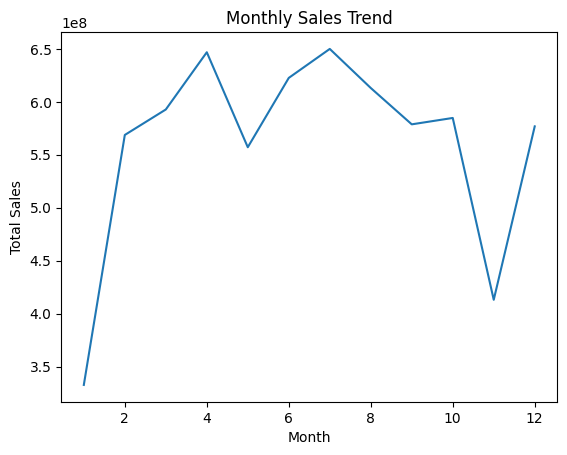

In [32]:
monthly_sales = df.groupby('month')['weekly_sales'].sum()
print(monthly_sales)

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

holiday_flag
0    1.041256e+06
1    1.122888e+06
Name: weekly_sales, dtype: float64


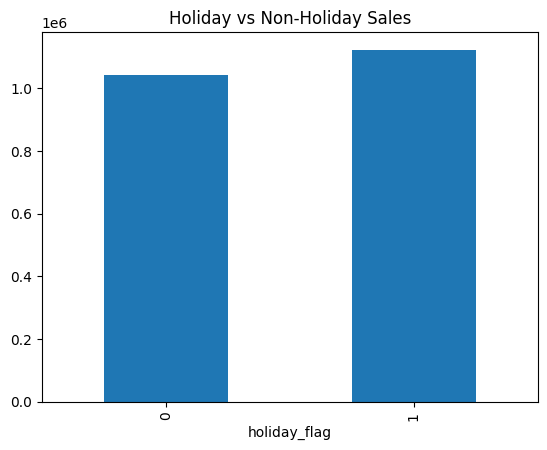

In [33]:
holiday_sales = df.groupby('holiday_flag')['weekly_sales'].mean()
print(holiday_sales)

holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [34]:
holiday_store_sales = df[df['holiday_flag'] == 1].groupby('store')['weekly_sales'].sum()
print(holiday_store_sales.sort_values(ascending=False))

store
20    22490340.0
4     22431030.0
14    21205830.0
10    21137570.0
13    21130430.0
2     20792670.0
27    18922980.0
6     16809070.0
1     16657470.0
19    15770470.0
39    15511280.0
31    15000270.0
28    14782450.0
24    14750990.0
23    14625410.0
11    14483930.0
41    13349460.0
32    12037864.0
18    11694217.0
12    11381403.0
22    10848746.0
35    10743490.0
26    10720462.0
34    10419786.0
40    10080336.0
17     9797969.0
8      9753299.0
45     8362935.0
21     8264910.0
25     7396766.0
15     7064063.0
7      6724003.0
43     6359462.0
29     6069579.0
9      5889508.0
42     5676941.0
16     5667337.0
37     5075251.0
3      4378111.0
30     4368593.0
38     3815099.0
36     3676408.0
5      3595017.0
44     2960355.0
33     2625946.0
Name: weekly_sales, dtype: float64


In [35]:
overall_avg = df['weekly_sales'].mean()

store_avg = df.groupby('store')['weekly_sales'].mean()
above_avg_stores = store_avg[store_avg > overall_avg]

print("Stores Above Overall Average:")
print(above_avg_stores)

Stores Above Overall Average:
store
1     1.555264e+06
2     1.925752e+06
4     2.094713e+06
6     1.564728e+06
10    1.899425e+06
11    1.356383e+06
13    2.003620e+06
14    2.020978e+06
18    1.084718e+06
19    1.444999e+06
20    2.107677e+06
23    1.389864e+06
24    1.356755e+06
27    1.775216e+06
28    1.323522e+06
31    1.395901e+06
32    1.166568e+06
39    1.450668e+06
41    1.268125e+06
Name: weekly_sales, dtype: float64


Correlation between Sales and Unemployment: -0.10617605596186816


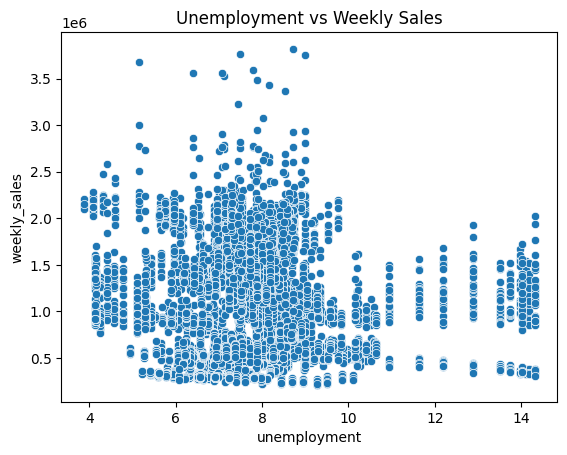

In [36]:
correlation_unemp = df['weekly_sales'].corr(df['unemployment'])
print("Correlation between Sales and Unemployment:", correlation_unemp)

sns.scatterplot(x='unemployment', y='weekly_sales', data=df)
plt.title("Unemployment vs Weekly Sales")
plt.show()

Correlation between Sales and Temperature: -0.06381001231613422


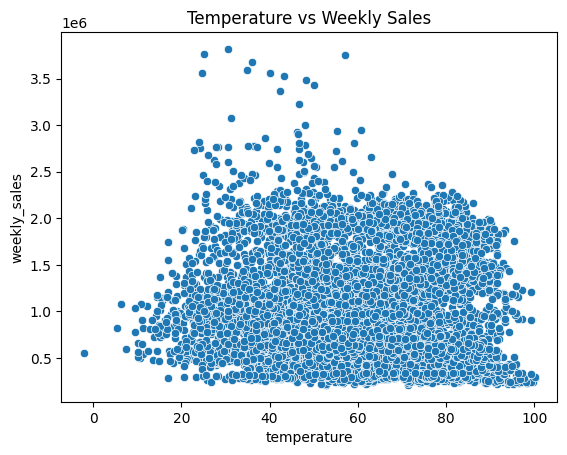

In [37]:
correlation_temp = df['weekly_sales'].corr(df['temperature'])
print("Correlation between Sales and Temperature:", correlation_temp)

sns.scatterplot(x='temperature', y='weekly_sales', data=df)
plt.title("Temperature vs Weekly Sales")
plt.show()

In [38]:
highest_month = monthly_sales.idxmax()
print("Month with Highest Sales:", highest_month)

Month with Highest Sales: 7
